In [2]:
import pandas as pd
import numpy as np

In [10]:
import re
from pathlib import Path

backbone_list = ["N","C","CA","O"]
intra_capsomer = ["#2//chain_id='A-52'","#2//chain_id='A-56'","#2//chain_id='A-15'","#2//chain_id='A'"]
inter_capsomer = ["#2//chain_id='A-36'","#2//chain_id='A-54'","#2//chain_id='A-55'","#2//chain_id='A-58'","#2//chain_id='A-60'"]
intake_list =[]

for file in Path("./").glob("all_contacts_A-53.txt"):
    with open(file) as in_file:
        for line in in_file:
            if line.startswith("8DES"):
                columns = line.strip().split()
                # print(columns)
                if  columns[4] in backbone_list and columns[9] in backbone_list:
                    next
                else:
                    if "chain_id='A-53'" in columns[1] and "chain_id='A-53'" in columns[6] :
                        intake_list.append([columns[1], columns[2],columns[3],columns[4],columns[6],columns[7],columns[8],columns[9],columns[10],columns[11],"self"])
                    elif "chain_id='A-53'" in columns[1] and columns[6] in intra_capsomer:
                        intake_list.append([columns[1], columns[2],columns[3],columns[4],columns[6],columns[7],columns[8],columns[9],columns[10],columns[11],"intra_capsomer"])
                    elif "chain_id='A-53'" in columns[1] and columns[6] in inter_capsomer:
                        intake_list.append([columns[1], columns[2],columns[3],columns[4],columns[6],columns[7],columns[8],columns[9],columns[10],columns[11],"inter_capsomer"])

In [11]:
len(intake_list)
# intake_list

2595

In [12]:
df = pd.DataFrame(intake_list, columns=["chain_A","A_AA","A_pos","A_atom","chain_B","B_AA","B_pos","B_atom","overlap","distance","interaction"])
df.loc[df['B_pos'] == "8"]

,chain_A,A_AA,A_pos,A_atom,chain_B,B_AA,B_pos,B_atom,overlap,distance,interaction
58,#2//chain_id='A-53',ASP,543,CG,#2//chain_id='A-58',VAL,8,CG2,0.848,2.912,inter_capsomer
80,#2//chain_id='A-53',ASP,543,OD2,#2//chain_id='A-58',VAL,8,CG2,0.679,2.621,inter_capsomer
276,#2//chain_id='A-53',ASP,543,OD1,#2//chain_id='A-58',VAL,8,CG2,0.162,3.138,inter_capsomer
566,#2//chain_id='A-53',LEU,67,N,#2//chain_id='A-58',VAL,8,CG1,-0.020,3.540,inter_capsomer
1097,#2//chain_id='A-53',LEU,67,CB,#2//chain_id='A-58',VAL,8,CG1,-0.154,3.914,inter_capsomer
1193,#2//chain_id='A-53',ASP,543,CB,#2//chain_id='A-58',VAL,8,CG2,-0.175,3.935,inter_capsomer
1311,#2//chain_id='A-53',VAL,66,C,#2//chain_id='A-58',VAL,8,CG1,-0.198,3.688,inter_capsomer
1742,#2//chain_id='A-53',SER,65,CB,#2//chain_id='A-58',VAL,8,CG1,-0.275,4.035,inter_capsomer
1778,#2//chain_id='A-53',VAL,66,CA,#2//chain_id='A-58',VAL,8,CG1,-0.281,4.041,inter_capsomer
2015,#2//chain_id='A-53',PHE,545,CB,#2//chain_id='A-58',VAL,8,CB,-0.317,4.077,inter_capsomer


In [13]:
df_deduplicated = df.drop_duplicates()      #because A-53 - to - A-53 contacts are in each contacts txt file from chimeraX
df_deduplicated['A_pos'] = df_deduplicated['A_pos'].astype(int)
df_deduplicated['B_pos'] = df_deduplicated['B_pos'].astype(int)

# df_deduplicated.to_csv("all_contacts_dataframe.tsv", sep='\t', index=False)
df_deduplicated

,chain_A,A_AA,A_pos,A_atom,chain_B,B_AA,B_pos,B_atom,overlap,distance,interaction
0,#2//chain_id='A-53',LEU,562,CA,#2//chain_id='A-58',ASP,564,OD2,3.126,0.174,inter_capsomer
1,#2//chain_id='A-53',ASP,564,OD2,#2//chain_id='A-36',LEU,562,CA,3.126,0.174,inter_capsomer
2,#2//chain_id='A-53',GLN,361,NE2,#2//chain_id='A-60',GLN,361,NE2,2.723,0.557,inter_capsomer
3,#2//chain_id='A-53',ASP,564,CG,#2//chain_id='A-36',LEU,562,N,2.696,0.824,inter_capsomer
4,#2//chain_id='A-53',LEU,562,N,#2//chain_id='A-58',ASP,564,CG,2.695,0.825,inter_capsomer
...,...,...,...,...,...,...,...,...,...,...,...
2590,#2//chain_id='A-53',PHE,152,CE2,#2//chain_id='A-53',ALA,133,N,-0.399,3.799,self
2591,#2//chain_id='A-53',ALA,202,C,#2//chain_id='A-53',LEU,517,CD2,-0.399,3.889,self
2592,#2//chain_id='A-53',PHE,474,CE1,#2//chain_id='A-53',LEU,517,N,-0.400,3.800,self
2593,#2//chain_id='A-53',ILE,117,CD1,#2//chain_id='A-53',PHE,102,CE2,-0.400,4.040,self


In [14]:
df_deduplicated.groupby("interaction").count()

,chain_A,A_AA,A_pos,A_atom,chain_B,B_AA,B_pos,B_atom,overlap,distance
interaction,,,,,,,,,,
inter_capsomer,584,584,584,584,584,584,584,584,584,584
intra_capsomer,233,233,233,233,233,233,233,233,233,233
self,1778,1778,1778,1778,1778,1778,1778,1778,1778,1778


In [15]:
df_feature_imp = pd.read_csv("/Users/varadakhot/Library/CloudStorage/OneDrive-Friedrich-Schiller-UniversitätJena/MCP_struct/RF_models_automation/RF_results/Rep_Seq_Position_Mapping/example_phyloglm/zvalue/cluster_phyloglm_zvalue_new_01_EC6098_reference_feature_importance.tsv",
                             sep='\t',usecols=["index","gini_imp","seq_position"]).reset_index(names="feat_rank")
df_feature_imp = df_feature_imp.loc[df_feature_imp['gini_imp'] > 0]
df_feature_imp

,feat_rank,index,gini_imp,seq_position
0,0,524_T,9.192288,524
1,1,555_M,8.970858,555
2,2,522_Q,8.940765,522
3,3,18_A,8.855942,18
4,4,537_Q,8.847490,537
...,...,...,...,...
649,649,371_R,3.215202,371
650,650,10_N,3.214805,10
651,651,122_A,3.213231,122
652,652,107_N,3.206090,107


In [16]:
#merge with duplicated(all) interactions
# Merge A features (keep all)
merged_A = df_deduplicated.merge(df_feature_imp
    , how="right", left_on="A_pos", right_on="seq_position")
merged_A.sort_values('feat_rank')

merged_B = merged_A.merge(df_feature_imp
    , how="left", left_on="B_pos", right_on="seq_position", suffixes=['_A','_B'])
merged_B.sort_values('feat_rank_A')


,chain_A,A_AA,A_pos,A_atom,chain_B,B_AA,B_pos,B_atom,overlap,distance,interaction,feat_rank_A,index_A,gini_imp_A,seq_position_A,feat_rank_B,index_B,gini_imp_B,seq_position_B
0,#2//chain_id='A-53',GLU,524.0,CA,#2//chain_id='A-53',LYS,194.0,CG,-0.002,3.762,self,0,524_T,9.192288,524,262.0,194_Q,4.357662,194.0
1,#2//chain_id='A-53',GLU,524.0,CB,#2//chain_id='A-53',ARG,192.0,O,-0.058,3.358,self,0,524_T,9.192288,524,NaN,NaN,NaN,NaN
2,#2//chain_id='A-53',GLU,524.0,CG,#2//chain_id='A-53',PRO,526.0,CD,-0.081,3.841,self,0,524_T,9.192288,524,NaN,NaN,NaN,NaN
3,#2//chain_id='A-53',GLU,524.0,CD,#2//chain_id='A-53',ASN,525.0,N,-0.120,3.640,self,0,524_T,9.192288,524,NaN,NaN,NaN,NaN
4,#2//chain_id='A-53',GLU,524.0,C,#2//chain_id='A-53',PRO,526.0,CD,-0.370,3.860,self,0,524_T,9.192288,524,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5676,#2//chain_id='A-53',LYS,107.0,O,#2//chain_id='A-60',SER,171.0,OG,0.262,2.218,inter_capsomer,652,107_N,3.206090,107,267.0,171_V,4.333836,171.0
5680,#2//chain_id='A-53',LYS,107.0,C,#2//chain_id='A-60',SER,171.0,OG,-0.228,3.298,inter_capsomer,652,107_N,3.206090,107,267.0,171_V,4.333836,171.0
5686,#2//chain_id='A-53',PRO,22.0,CD,#2//chain_id='A-36',TYR,557.0,CD1,0.089,3.551,inter_capsomer,653,22_H,3.204014,22,594.0,557_G,3.322359,557.0
5685,#2//chain_id='A-53',PRO,22.0,CD,#2//chain_id='A-36',TYR,557.0,CD1,0.089,3.551,inter_capsomer,653,22_H,3.204014,22,377.0,557_S,3.918247,557.0


In [9]:
merged_B['interaction'] = merged_B['interaction'].fillna('non-interacting')
df_merged = merged_B
# df_merged.fillna("unknown",inplace=True)
df_merged['distance'].replace(np.nan, 8.0, inplace=True)
# df_merged.to_csv("contacts_only_with_feat_imp.tsv", sep='\t', index=False)
df_merged.sort_values('feat_rank_A')
df_merged.to_csv("new_comparisons/RF/all_contacts_with_feat_imp.tsv", sep='\t', index=False)


/var/folders/6c/dkl_rmf913l9h4s3pys_spm80000gn/T/ipykernel_78473/1979325873.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['distance'].replace(np.nan, 8.0, inplace=True)


In [10]:
df_merged

,chain_A,A_AA,A_pos,A_atom,chain_B,B_AA,B_pos,B_atom,overlap,distance,interaction,feat_rank_A,index_A,gini_imp_A,seq_position_A,feat_rank_B,index_B,gini_imp_B,seq_position_B
0,#2//chain_id='A-53',GLU,524.0,CG,#2//chain_id='A-53',GLY,44.0,CA,0.192,3.568,self,0,524_T,9.192288,524,347.0,44_Y,4.046525,44.0
1,#2//chain_id='A-53',GLU,524.0,CG,#2//chain_id='A-53',GLY,44.0,CA,0.192,3.568,self,0,524_T,9.192288,524,427.0,44_L,3.752561,44.0
2,#2//chain_id='A-53',GLU,524.0,CG,#2//chain_id='A-53',GLY,44.0,CA,0.192,3.568,self,0,524_T,9.192288,524,431.0,44_E,3.743437,44.0
3,#2//chain_id='A-53',GLU,524.0,CG,#2//chain_id='A-53',GLY,44.0,CA,0.192,3.568,self,0,524_T,9.192288,524,617.0,44_F,3.287291,44.0
4,#2//chain_id='A-53',GLU,524.0,CD,#2//chain_id='A-53',PRO,526.0,CD,0.105,3.655,self,0,524_T,9.192288,524,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4421,#2//chain_id='A-53',LYS,107.0,O,#2//chain_id='A-60',SER,171.0,OG,0.262,2.218,inter_capsomer,652,107_N,3.206090,107,267.0,171_V,4.333836,171.0
4422,#2//chain_id='A-53',LYS,107.0,O,#2//chain_id='A-60',SER,171.0,OG,0.262,2.218,inter_capsomer,652,107_N,3.206090,107,514.0,171_A,3.529846,171.0
4423,#2//chain_id='A-53',LYS,107.0,CG,#2//chain_id='A-60',SER,171.0,CB,-0.393,4.153,inter_capsomer,652,107_N,3.206090,107,267.0,171_V,4.333836,171.0
4424,#2//chain_id='A-53',LYS,107.0,CG,#2//chain_id='A-60',SER,171.0,CB,-0.393,4.153,inter_capsomer,652,107_N,3.206090,107,514.0,171_A,3.529846,171.0


/var/folders/6c/dkl_rmf913l9h4s3pys_spm80000gn/T/ipykernel_78473/2212331059.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['interaction', 'rank_group'])
/var/folders/6c/dkl_rmf913l9h4s3pys_spm80000gn/T/ipykernel_78473/2212331059.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df['fraction'] = count_df.groupby('rank_group')['count'].transform(lambda x: x / x.sum())


<Figure size 1000x600 with 0 Axes>

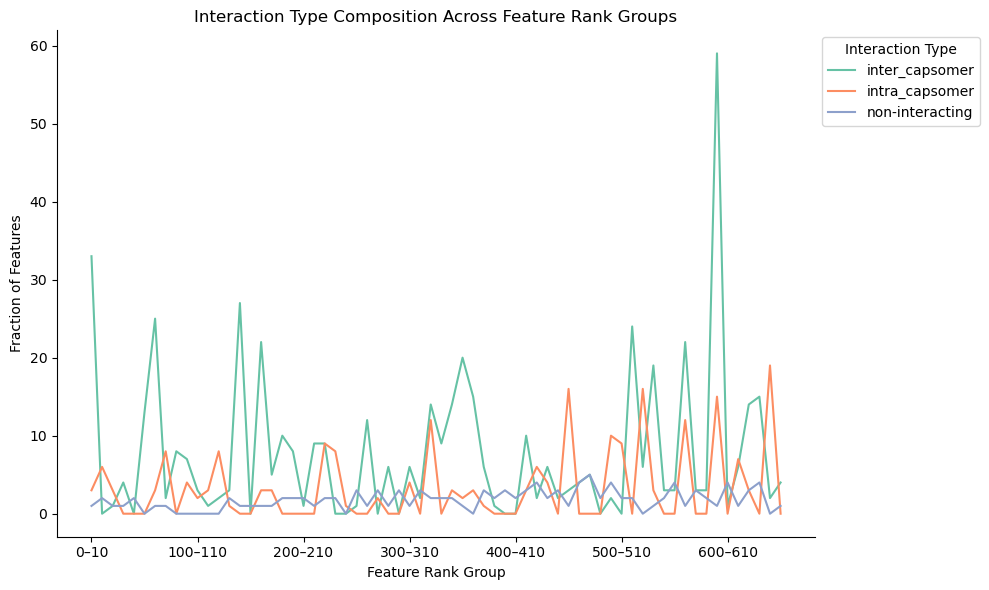

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df_merged
df = df.loc[~(df['interaction'] == "self")]
# Melt to have both A and B ranks in one column
df_melt = df.melt(
    id_vars=['interaction'],
    value_vars=['feat_rank_A'],
    var_name='rank_type',
    value_name='feature_rank'
)

# Define bins: 0–20, 20–40, 40–60, ... up to 500, then 500+
bins = list(np.arange(0, 660, 10)) + [float('inf')]
labels = [f"{i}–{i+10}" for i in range(0, 650, 10)] + ["650+"]

df_melt['rank_group'] = pd.cut(df_melt['feature_rank'], bins=bins, labels=labels, right=True)

# Count how many residues fall into each (interaction, rank_group)
count_df = (
    df_melt
    .groupby(['interaction', 'rank_group'])
    .size()
    .reset_index(name='count')
)

# Normalize by interaction type to show relative proportions
count_df['fraction'] = count_df.groupby('rank_group')['count'].transform(lambda x: x / x.sum())

pivot_df = count_df.pivot(index='rank_group', columns='interaction', values='count').fillna(0)

plt.figure(figsize=(10,6))

pivot_df.plot(
    kind='line',
    figsize=(10,6),
    color=sns.color_palette('Set2', n_colors=pivot_df.shape[1])
)
plt.ylabel('Fraction of Features')
plt.xlabel('Feature Rank Group')
plt.title('Interaction Type Composition Across Feature Rank Groups')
plt.legend(title='Interaction Type', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

/var/folders/6c/dkl_rmf913l9h4s3pys_spm80000gn/T/ipykernel_78473/3079331671.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['interaction', 'rank_group'])


<Figure size 1000x600 with 0 Axes>

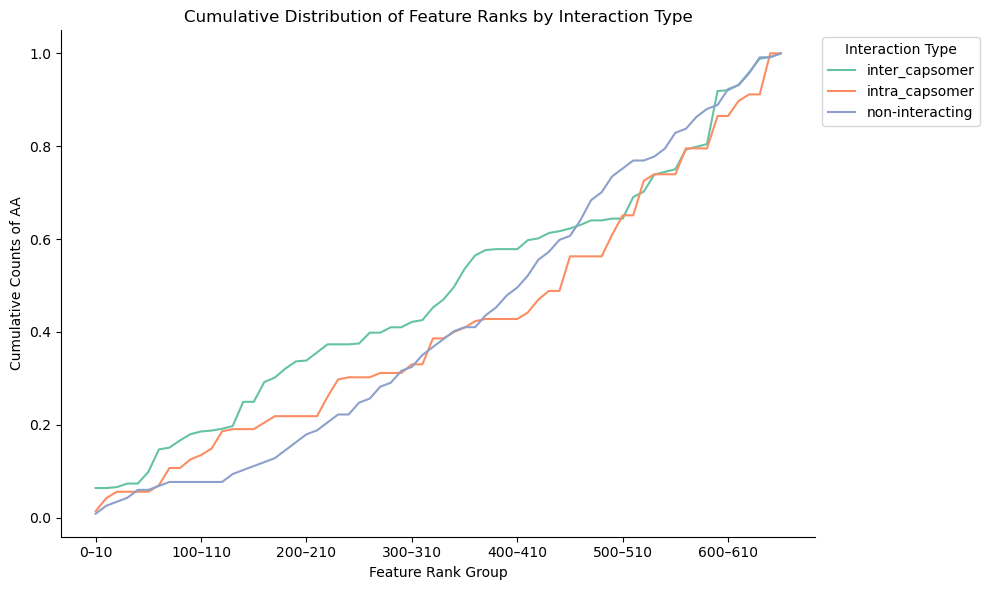

In [12]:
df = df_merged
df = df.loc[~(df['interaction'] == "self")]
# Melt to have both A and B ranks in one column
df_melt = df.melt(
    id_vars=['interaction'],
    value_vars=['feat_rank_A'],
    var_name='rank_type',
    value_name='feature_rank'
)

# Define bins: 0–20, 20–40, 40–60, ... up to 500, then 500+
bins = list(np.arange(0, 660, 10)) + [float('inf')]
labels = [f"{i}–{i+10}" for i in range(0, 650, 10)] + ["650+"]

df_melt['rank_group'] = pd.cut(df_melt['feature_rank'], bins=bins, labels=labels, right=True)

# Count how many residues fall into each (interaction, rank_group)
count_df = (
    df_melt
    .groupby(['interaction', 'rank_group'])
    .size()
    .reset_index(name='count')
)

# Normalize by interaction type to show relative proportions
# count_df['fraction'] = count_df.groupby('rank_group')['count'].transform(lambda x: x)

pivot_df = count_df.pivot(index='rank_group', columns='interaction', values='count').fillna(0)
# Convert counts into cumulative distribution per interaction
cdf_df = pivot_df.cumsum()             # cumulative sum down the rank groups
cdf_df = cdf_df / cdf_df.max()         # normalize each column to 1 (convert to CDF)

plt.figure(figsize=(10,6))

cdf_df.plot(
    kind='line',
    figsize=(10,6),
    color=sns.color_palette('Set2', n_colors=cdf_df.shape[1])
)

plt.ylabel('Cumulative Counts of AA')
plt.xlabel('Feature Rank Group')
plt.title('Cumulative Distribution of Feature Ranks by Interaction Type')
plt.legend(title='Interaction Type', bbox_to_anchor=(1, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()


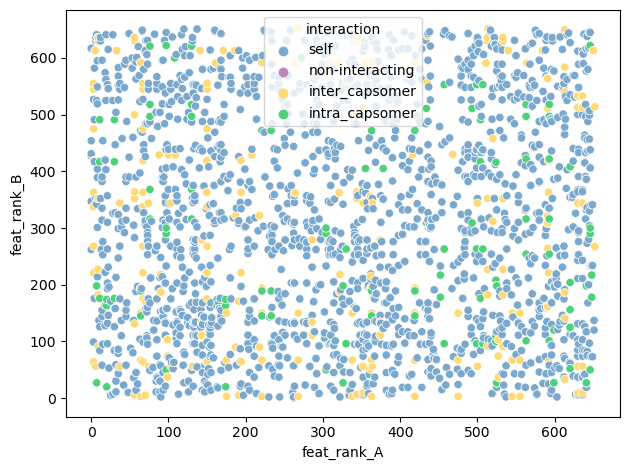

In [13]:
my_palette = ["#7AA9CD","#C185B8","#FFD972","#4DD179"]
sns.scatterplot(df_merged,x="feat_rank_A",y="feat_rank_B",hue="interaction",palette=my_palette)
plt.tight_layout()
plt.show()

In [22]:
df = df_merged
# df = df.loc[(df['side'] == "B") & (df['feat_rank'] <= 500)]
# Melt to have both A and B ranks in one column
df['distance'] = df['distance'].astype(float)
df_melt = df.melt(
    id_vars=['interaction','distance'],
    var_name='rank_type',
    value_vars=['feat_rank_A'],
    value_name='feature_rank'
)
df_melt


,interaction,distance,rank_type,feature_rank
0,self,3.568,feat_rank_A,0
1,self,3.568,feat_rank_A,0
2,self,3.568,feat_rank_A,0
3,self,3.568,feat_rank_A,0
4,self,3.655,feat_rank_A,0
...,...,...,...,...
4421,inter_capsomer,2.218,feat_rank_A,652
4422,inter_capsomer,2.218,feat_rank_A,652
4423,inter_capsomer,4.153,feat_rank_A,652
4424,inter_capsomer,4.153,feat_rank_A,652


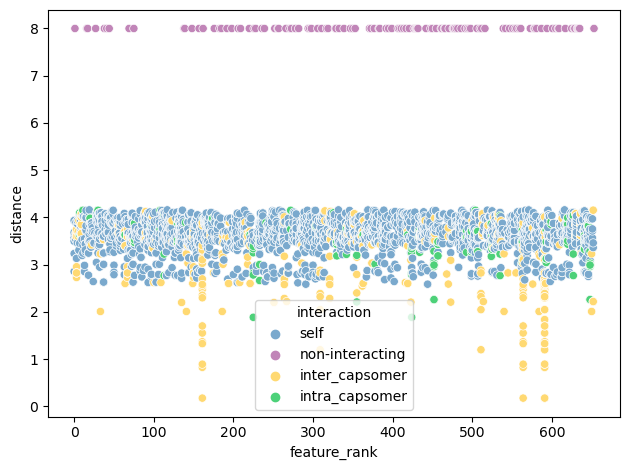

In [23]:
my_palette = ["#7AA9CD","#C185B8","#FFD972","#4DD179"]
sns.scatterplot(df_melt,x="feature_rank",y="distance",hue="interaction",palette=my_palette)
plt.tight_layout()
plt.show()

/var/folders/6c/dkl_rmf913l9h4s3pys_spm80000gn/T/ipykernel_77877/3075447108.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['interaction', 'rank_group'])
/var/folders/6c/dkl_rmf913l9h4s3pys_spm80000gn/T/ipykernel_77877/3075447108.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df['fraction'] = count_df.groupby('rank_group')['count'].transform(lambda x: x / x.sum())


<Figure size 1000x600 with 0 Axes>

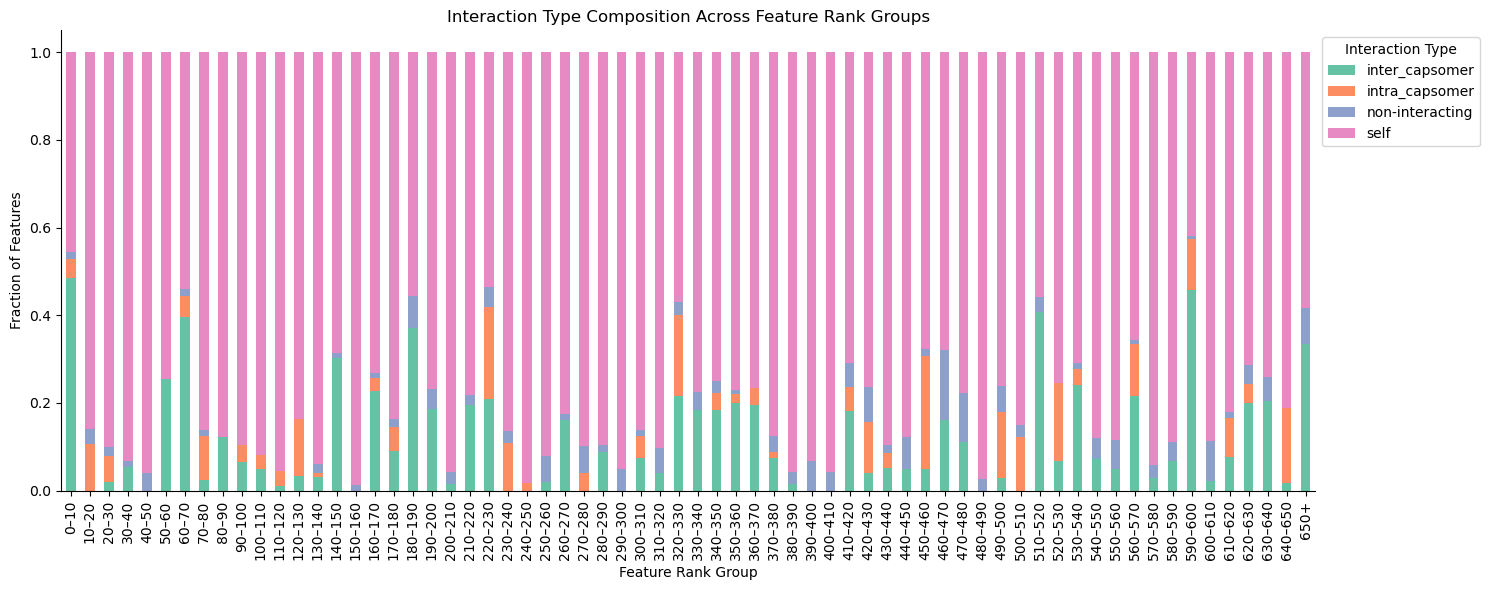

In [24]:

# Define bins: 0–20, 20–40, 40–60, ... up to 500, then 500+
bins = list(np.arange(0, 660, 10)) + [float('inf')]
labels = [f"{i}–{i+10}" for i in range(0, 650, 10)] + ["650+"]

df_melt['rank_group'] = pd.cut(df_melt['feature_rank'], bins=bins, labels=labels, right=True)

# Count how many residues fall into each (interaction, rank_group)
count_df = (
    df_melt
    .groupby(['interaction', 'rank_group'])
    .size()
    .reset_index(name='count')
)

# Normalize by interaction type to show relative proportions
count_df['fraction'] = count_df.groupby('rank_group')['count'].transform(lambda x: x / x.sum())

pivot_df = count_df.pivot(index='rank_group', columns='interaction', values='fraction').fillna(0)

plt.figure(figsize=(10,6))

pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(15,6),
    color=sns.color_palette('Set2', n_colors=pivot_df.shape[1])
)
plt.ylabel('Fraction of Features')
plt.xlabel('Feature Rank Group')
plt.title('Interaction Type Composition Across Feature Rank Groups')
plt.legend(title='Interaction Type', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()